In [1]:
import numpy as np

In [113]:
h = 0.1
N = 100
L = 1

In [114]:
def update_p_pos(q, p, mu):
    mu_full = np.hstack((mu, np.zeros((2, 1))))
    return p - h/2*(mu_full - np.roll(mu_full, 2))

In [115]:
q = np.array([[1, 2, 3], [4, 5, 6]])
p = np.array([[1, 2, 3], [4, 5, 6]])
mu = np.array([[10, 20], [30, 40]])

update_p_pos(q, p, mu)


array([[2.5, 1. , 3.5],
       [3.5, 3. , 7.5]])

In [116]:
def update_p_angle(theta, xi, mu):
    mu_full = np.hstack((mu, np.zeros((2, 1))))
    c = mu_full + np.roll(mu_full, 2)
    cx = c[0]
    cy = c[1]
    delta_xi = -np.sin(theta)*cx + np.cos(theta)*cy
    return xi - h*L/2*delta_xi

In [117]:
theta = np.array([1, 2, 3])
xi = np.array([0, 0, 0])

update_p_angle(theta, xi, mu)

array([0.7529217 , 1.7415911 , 1.55554875])

In [118]:
def update_q(q, p):
    return q + h*p

In [119]:
def constraint(q, theta):
    delta_q = q[:, :-1] - q[:, 1:]
    delta_qx = delta_q[0]  # TODO simplify
    delta_qy = delta_q[1]
    
    sx = L*(np.cos(theta[:-1]) + np.cos(theta[1:]))
    sy = L*(np.sin(theta[:-1]) + np.sin(theta[1:]))
    
    return np.hstack((delta_qx + sx, delta_qy + sy))

In [120]:
constraint(q, theta)

array([-0.87584453, -2.40613933,  0.75076841,  0.05041743])

In [121]:
q = np.zeros((2, N))
theta = np.zeros(N)
theta[1::2] = np.pi/4 

for i in range(1, N):
    q[0, i] = q[0, i-1] + L*np.cos(theta[i]) + L*np.cos(theta[i-1])
    q[1, i] = q[1, i-1] + L*np.sin(theta[i]) + L*np.sin(theta[i-1])    

In [122]:
np.max(np.abs(constraint(q, theta)))

5.773159728050814e-15

In [123]:
xi = np.cos(np.linspace(0, np.pi, N))

p = np.zeros((2, N))
for i in range(1, N):
    p[0, i] = p[0, i-1] - L*np.sin(theta[i-1])*xi[i-1] - L*np.sin(theta[i])*xi[i] 
    p[1, i] = p[1, i-1] + L*np.cos(theta[i-1])*xi[i-1] + L*np.cos(theta[i])*xi[i]

In [124]:
p.shape

(2, 100)

In [125]:
def objective(mu, q0, p0, theta0, xi0):
    p1 = update_p_pos(q0, p0, mu)
    xi1 = update_p_angle(theta0, xi0, mu)
    q1 = update_q(q0, p1)
    theta1 = update_q(theta0, xi1)
    return constraint(q1, theta1)
    

In [126]:
mu0 = np.zeros((2, N-1))

objective(mu0, q, p, theta, xi)

array([-8.40725571e-03, -8.38717618e-03, -8.36025106e-03, -8.30033476e-03,
       -8.24689971e-03, -8.14810836e-03, -8.06898790e-03, -7.93290733e-03,
       -7.82932364e-03, -7.65813855e-03, -7.53169415e-03, -7.32815320e-03,
       -7.18080813e-03, -6.94818015e-03, -6.78222390e-03, -6.52424565e-03,
       -6.34226421e-03, -6.06308067e-03, -5.86791899e-03, -5.57201707e-03,
       -5.36673748e-03, -5.05887413e-03, -4.84671115e-03, -4.53183711e-03,
       -4.31614922e-03, -3.99932952e-03, -3.78354857e-03, -3.46988117e-03,
       -3.25746008e-03, -2.95199378e-03, -2.74635325e-03, -2.45400637e-03,
       -2.25848136e-03, -1.98396238e-03, -1.80174923e-03, -1.54948074e-03,
       -1.38358568e-03, -1.15763288e-03, -1.01082273e-03, -8.14827610e-04,
       -6.89583653e-04, -5.26705997e-04, -4.25181608e-04, -2.98047761e-04,
       -2.22030746e-04, -1.32690990e-04, -8.35712469e-05, -3.34665152e-05,
       -1.22096971e-05, -2.14816865e-06, -9.27591009e-06, -3.94198803e-05,
       -7.49970521e-05, -

In [127]:
from scipy.optimize import root

In [128]:
def flat_objective(mu_flat, q, p, theta, xi):
    mu = mu_flat.reshape(2, -1)
    return objective(mu, q, p, theta, xi)

In [129]:
mu0_flat = mu0.reshape(-1)
res = root(flat_objective, mu0_flat, args=(q, p, theta, xi))

In [130]:
res

    fjac: array([[-5.77219321e-01, -5.77380034e-01,  5.77451213e-01, ...,
         1.77476832e-05,  2.02163248e-05,  1.33989547e-06],
       [ 1.23972495e-01, -6.97219033e-01, -5.73265136e-01, ...,
         4.37967191e-05,  4.86154536e-05,  4.23465361e-06],
       [-3.91660254e-01,  7.31043586e-02, -3.18433166e-01, ...,
         6.93883267e-05,  7.82181573e-05,  5.80566222e-06],
       ...,
       [-1.54790781e-02,  5.96641937e-03, -9.33749960e-03, ...,
        -5.76775653e-01, -5.86375402e-01,  1.07496548e-01],
       [-3.21713748e-03,  1.24007552e-03, -1.93970851e-03, ...,
        -4.75617478e-02,  6.63392532e-02, -9.43342190e-01],
       [-1.45069807e-03,  5.40724153e-04, -8.98944614e-04, ...,
        -1.10951490e-01,  1.14532431e-01, -1.67232339e-01]])
     fun: array([-8.65973959e-15, -6.66133815e-16,  8.88178420e-16,  3.99680289e-15,
        8.65973959e-15,  1.46549439e-14,  1.68753900e-14,  1.99840144e-14,
        2.22044605e-14,  1.73194792e-14,  1.82076576e-14,  1.48769885e-14

In [112]:
%matplotlib inline

In [132]:
import matplotlib.pyplot as plt

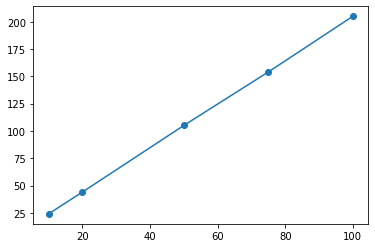

In [136]:
n = [10, 20, 50, 75, 100]
nfev = [24, 44, 105, 154, 205]

plt.plot(n, nfev, 'o-')